In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install -U open-clip-torch
import os, re
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader, random_split, TensorDataset
from sklearn.metrics import classification_report
import open_clip
from torch.utils.data import WeightedRandomSampler, DataLoader
import matplotlib.pyplot as plt



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [3]:
!rm -rf covid-chestxray-dataset-master.zip covid-chestxray-dataset-master
!wget https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip -O covid.zip
!unzip -q covid.zip
!mv covid-chestxray-dataset-master covid
print("Dataset restored!")


--2026-04-22 14:15:00--  https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/ieee8023/covid-chestxray-dataset/zip/refs/heads/master [following]
--2026-04-22 14:15:00--  https://codeload.github.com/ieee8023/covid-chestxray-dataset/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.113.9
Connecting to codeload.github.com (codeload.github.com)|140.82.113.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘covid.zip’

covid.zip               [<=>                 ] 525.03M  16.1MB/s    in 30s     

2026-04-22 14:15:31 (17.3 MB/s) - ‘covid.zip’ saved [550535079]

Dataset restored!


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
META_PATH = "/content/covid/metadata.csv"
IMG_ROOT  = "/content/covid/images"
df = pd.read_csv(META_PATH)

def clean_text(x):
    if pd.isna(x):
        return None
    return re.sub(r"\s+", " ", str(x).strip())

df["finding"] = df["finding"].apply(clean_text)

#LABEL MAPPING
LABEL_MAP = {
    "No Finding": "Normal",
    "Pneumonia/Viral/COVID-19": "COVID-19",
    "Pneumonia/Viral/Herpes": "Viral(Except COVID-19)",
    "Pneumonia/Viral/Influenza": "Viral(Except COVID-19)",
    "Pneumonia/Viral/Influenza/H1N1": "Viral(Except COVID-19)",
    "Pneumonia/Viral/MERS-CoV": "Viral(Except COVID-19)",
    "Pneumonia/Viral/SARS": "Viral(Except COVID-19)",
    "Pneumonia/Viral/Varicella": "Viral(Except COVID-19)",
    "Pneumonia/Bacterial/Streptococcus": "Bacterial",
    "Pneumonia/Bacterial/E.Coli": "Bacterial",
    "Pneumonia/Bacterial/Chlamydophila": "Bacterial",
    "Pneumonia/Bacterial/Klebsiella": "Bacterial",
    "Pneumonia/Bacterial": "Bacterial",
    "Pneumonia/Bacterial/Legionella": "Bacterial",
    "Pneumonia/Bacterial/Mycoplasma": "Bacterial",
    "Pneumonia/Bacterial/Nocardia": "Bacterial",
    "Pneumonia/Bacterial/Staphylococcus/MRSA": "Bacterial",
    "Pneumonia": "generic/ambiguous pneumonia",
    "Pneumonia/Aspiration": "Aspiration",
    "Pneumonia/Lipoid": "Lipoid",
    "Tuberculosis": "Tuberculosis",
    "Pneumonia/Fungal/Pneumocystis": "Pneumocystis",
    "Pneumonia/Fungal/Aspergillosis": "Aspergillosis",
}

df["label"] = df["finding"].map(LABEL_MAP)
df = df[df["label"].notna()].reset_index(drop=True)
TRAIN_CLASSES = ["Normal", "Viral(Except COVID-19)", "Bacterial", "COVID-19"]
TEST_CLASSES = ["generic/ambiguous pneumonia", "Pneumocystis", "Tuberculosis", "Lipoid", "Aspergillosis", "Aspiration"]

train_label_to_idx = {c: i for i, c in enumerate(TRAIN_CLASSES)}
trainval_df = df[df["label"].isin(TRAIN_CLASSES)].copy()
trainval_df["label_idx"] = trainval_df["label"].map(train_label_to_idx)
test_df = df[df["label"].isin(TEST_CLASSES)].copy()
def resolve_path(fname):
    base = os.path.join(IMG_ROOT, str(fname))
    for ext in ["", ".png", ".jpg", ".jpeg"]:
        if os.path.exists(base + ext): return base + ext
    return None

trainval_df["path"] = trainval_df["filename"].apply(resolve_path)
test_df["path"]     = test_df["filename"].apply(resolve_path)
trainval_df = trainval_df[trainval_df["path"].notna()].reset_index(drop=True)
test_df     = test_df[test_df["path"].notna()].reset_index(drop=True)

transform = T.Compose([
    T.Resize((224, 224)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class ChestXrayDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        return self.transform(img), int(row["label_idx"])

class ChestXrayOODDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        return self.transform(img)

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
full_trainval = ChestXrayDataset(trainval_df, transform)
indices = np.arange(len(trainval_df))
labels = trainval_df["label_idx"].values
train_idx, val_idx = train_test_split(
    indices,
    test_size=0.20,
    stratify=labels,
    random_state=42
)

train_ds = Subset(full_trainval, train_idx)
val_ds = Subset(full_trainval, val_idx)
train_labels = labels[train_idx]
class_sample_count = np.bincount(train_labels)
weights = 1. / torch.tensor(class_sample_count, dtype=torch.float)
samples_weights = weights[train_labels]

sampler = WeightedRandomSampler(
    weights=samples_weights,
    num_samples=len(samples_weights),
    replacement=True
)

# 8. LOADERS
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_ds      = ChestXrayOODDataset(test_df, transform)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

print("\nTrain/Val distribution:")
print(trainval_df["label"].value_counts())

print("\nTest (OOD) distribution:")
print(test_df["label"].value_counts())





Device: cuda

Train/Val distribution:
label
COVID-19                  563
Bacterial                  73
Viral(Except COVID-19)     42
Normal                     22
Name: count, dtype: int64

Test (OOD) distribution:
label
generic/ambiguous pneumonia    81
Pneumocystis                   30
Tuberculosis                   18
Lipoid                         13
Aspergillosis                   2
Aspiration                      1
Name: count, dtype: int64


In [ ]:
# 6. LOAD ViT-Base
import torch
import torch.nn as nn
from transformers import ViTModel, AutoTokenizer, AutoModel
import torch.nn.functional as F
import timm
model_name = "vit_base_patch16_224"
model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=0,
    global_pool=''
).to(device)

for p in model.parameters():
    p.requires_grad = True

print(f"Model '{model_name}' loaded via timm and unfrozen.")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model 'vit_base_patch16_224' loaded via timm and unfrozen.
Trainable params: 85,798,656


In [ ]:
# LOAD ViT-SMALL
import torch
import torch.nn as nn
from transformers import ViTModel, AutoTokenizer, AutoModel
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer

import timm
model_name = "vit_small_patch16_224"
model = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=0,
    global_pool=''
).to(device)
for p in model.parameters():
    p.requires_grad = True
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params: 21,665,664


In [5]:
#LOAD DINOv2-Small
import torch
import torch.nn as nn
from transformers import ViTModel, AutoTokenizer, AutoModel
import torch.nn.functional as F
from transformers import AutoModel, AutoTokenizer
import torch
import torch.nn as nn
import numpy as np

model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)

for param in model.parameters():
    param.requires_grad = True
projection = nn.Linear(384, 768).to(device)

logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

print(f"Backbone updated to DINOv2-Small (vits14).")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")





Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 178MB/s]


Backbone updated to DINOv2-Small (vits14).
Trainable params: 22,056,576


In [6]:
# 2. Load PubMedBERT (Text) - Remain Frozen
bert_name = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext"
pubmed_tokenizer = AutoTokenizer.from_pretrained(bert_name)
pubmed_model = AutoModel.from_pretrained(bert_name).to(device).eval()

for p in pubmed_model.parameters():
    p.requires_grad = False
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable params: 22,056,576


In [7]:

# 7. TEXT FEATURES
DESCRIPTIONS = {
    "Normal": "healthy lungs, no consolidation, no opacities, sharp costophrenic angles",
    "Viral(Except COVID-19)": "viral pneumonia with diffuse interstitial opacities",
    "Bacterial": "bacterial pneumonia with lobar consolidation",
    "COVID-19": "covid-19 pneumonia with bilateral ground-glass opacities"
}

TEMPLATES = [
    "a chest radiograph showing {}.",
    "radiographic findings of {}."
]

@torch.no_grad()
def build_text_features():
    feats = []
    for cls in TRAIN_CLASSES:
        prompts = [t.format(DESCRIPTIONS[cls]) for t in TEMPLATES]

        # PubMedBERT Tokenization
        inputs = pubmed_tokenizer(prompts, padding=True, truncation=True, return_tensors="pt").to(device)
        outputs = pubmed_model(**inputs)

        # Extract [CLS] token embeddings and normalize
        emb = outputs.last_hidden_state[:, 0, :]
        emb = F.normalize(emb, dim=-1)

        # Average the templates for the class
        feats.append(emb.mean(dim=0))

    feats = torch.stack(feats)
    return F.normalize(feats, dim=-1) # Dim: [4, 768]

text_features = build_text_features()
text_features = text_features - text_features.mean(dim=0, keepdim=True)
text_features = F.normalize(text_features, dim=-1)


In [ ]:
# ============================================================
# 8. LoRA-STYLE FEATURE ADAPTER (FIXED FOR TIMM)
# ============================================================
with torch.no_grad():
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    outputs = model(dummy)
    embed_dim = outputs.shape[-1]
    text_dim  = text_features.shape[-1]

print(f"Vision Dimension: {embed_dim}, Text Dimension: {text_dim}")

class FeatureAdapter(nn.Module):
    def __init__(self, in_dim, out_dim, r=16):
        super().__init__()
        self.down = nn.Linear(in_dim, r, bias=False)
        self.up   = nn.Linear(r, in_dim, bias=False)
        nn.init.zeros_(self.up.weight)
        self.proj = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        res = self.up(self.down(x))
        x = x + res
        return self.proj(x)



adapter = FeatureAdapter(embed_dim, text_dim).to(device)

# LOSS, OPTIMIZER
import numpy as np

train_labels = [train_ds[i][1] for i in range(len(train_ds))]
class_counts = np.bincount(train_labels, minlength=len(TRAIN_CLASSES))
class_weights = torch.tensor(
    1.0 / (class_counts + 1e-6), dtype=torch.float32, device=device
)

criterion = WeightedFocalLoss(weight=class_weights, gamma=2.0)
logit_scale = nn.Parameter(torch.ones([], device=device) * np.log(1 / 0.07))
optimizer = torch.optim.AdamW([
    {'params': model.parameters(),   'lr': 1e-7, 'weight_decay': 0.01},
    {'params': adapter.parameters(), 'lr': 1e-5, 'weight_decay': 0.01},
    {'params': [logit_scale],        'lr': 1e-5}

print("Setup complete for timm-based ViT architecture.")

Vision Dimension: 384, Text Dimension: 768
Setup complete for timm-based ViT architecture.


**improving the dinov2.**

In [8]:
# 8. LoRA-STYLE FEATURE ADAPTER
with torch.no_grad():
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)

    outputs = model(dummy)

    embed_dim = outputs.shape[-1]
    text_dim  = text_features.shape[-1]

print(f"Vision Dimension: {embed_dim}, Text Dimension: {text_dim}")

class FeatureAdapter(nn.Module):
    def __init__(self, in_dim, out_dim, r=8, dropout_rate=0.2):
        super().__init__()
        self.layernorm = nn.LayerNorm(in_dim)
        self.down = nn.Linear(in_dim, r, bias=False)
        self.up   = nn.Linear(r, in_dim, bias=False)
        nn.init.zeros_(self.up.weight)

        self.dropout = nn.Dropout(p=dropout_rate)
        self.proj_dim = nn.Linear(in_dim, out_dim)
        self.classifier = nn.Linear(out_dim, 4)

    def get_features(self, x):
        """Returns adapted features projected to Text Dimension (768)"""
        norm_x = self.layernorm(x)
        res = self.up(self.down(norm_x))
        x = x + (1 * res)
        return self.proj_dim(x)

    def forward(self, x):
        """Standard 4-class path"""
        feat = self.get_features(x)
        return self.classifier(self.dropout(feat))


class WeightedFocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=0.1)

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        return ((1 - pt) ** self.gamma * ce_loss).mean()

import numpy as np

adapter = FeatureAdapter(embed_dim, text_dim, r=8, dropout_rate=0.2).to(device)
train_indices = train_ds.indices
train_labels = full_trainval.df.iloc[train_indices]["label_idx"].values

class_counts = np.bincount(train_labels, minlength=len(TRAIN_CLASSES))


class_weights = torch.tensor([4.0, 10.0, 10.0, 13], dtype=torch.float32).to(device)
criterion = WeightedFocalLoss(weight=class_weights, gamma=2.0)
optimizer = torch.optim.AdamW([
    {'params': model.parameters(), 'lr': 1e-7},
    {'params': adapter.parameters(), 'lr': 2e-5, 'weight_decay': 0.05},
    {'params': [logit_scale], 'lr': 1e-4}
])

Vision Dimension: 384, Text Dimension: 768


In [ ]:
from tqdm import tqdm

EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60)
train_losses, train_accs = [], []
val_losses, val_accs = [], []

best_val_loss = float('inf')
checkpoint_path = "medical_best.pth"

for epoch in range(EPOCHS):
    model.train()
    adapter.train()

    correct = total = 0
    loss_sum = 0
    train_class_correct = {i: 0 for i in range(len(TRAIN_CLASSES))}
    train_class_total = {i: 0 for i in range(len(TRAIN_CLASSES))}

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)

        if hasattr(outputs, 'last_hidden_state'):
            feats = outputs.last_hidden_state[:, 0, :]
        elif len(outputs.shape) == 3:
            feats = outputs[:, 0, :]
        else:
            feats = outputs

        feats = adapter.get_features(feats)
        feats = F.normalize(feats, dim=-1)
        logits = logit_scale.exp() * (feats @ text_features.T)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        for label_idx in range(len(TRAIN_CLASSES)):
            mask = (labels == label_idx)
            if mask.sum() > 0:
                train_class_correct[label_idx] += (preds[mask] == labels[mask]).sum().item()
                train_class_total[label_idx] += mask.sum().item()

    train_losses.append(loss_sum / len(train_loader))
    train_accs.append(correct / total)

    print(f"\n--- Epoch {epoch+1} Training Summary ---")
    print(f"Overall Train Acc: {train_accs[-1]:.4f} | Train Loss: {train_losses[-1]:.4f}")
    print(f"{'Class Name':<25} | {'Train Acc':<10} | {'Correct/Total'}")
    print("-" * 55)
    for i, class_name in enumerate(TRAIN_CLASSES):
        if train_class_total[i] > 0:
            t_acc = train_class_correct[i] / train_class_total[i]
            print(f"{class_name:<25} | {t_acc:.2%} | {train_class_correct[i]}/{train_class_total[i]}")

    model.eval()
    adapter.eval()
    val_correct = val_total = 0
    val_loss_sum = 0
    class_correct = {i: 0 for i in range(len(TRAIN_CLASSES))}
    class_total = {i: 0 for i in range(len(TRAIN_CLASSES))}

    with torch.no_grad():
        noise = torch.randn_like(feats) * 0.05
        ood_feats = feats + noise
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            if hasattr(outputs, 'last_hidden_state'):
                feats = outputs.last_hidden_state[:, 0, :]
            elif len(outputs.shape) == 3:
                feats = outputs[:, 0, :]
            else:
                feats = outputs

            feats = adapter.get_features(feats)
            feats = F.normalize(feats, dim=-1)
            logits = (feats @ text_features.T)
            logits = logits / 0.05
            val_loss = criterion(logits, labels)
            val_loss_sum += val_loss.item()
            preds = logits.argmax(1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            for label_idx in range(len(TRAIN_CLASSES)):
                mask = (labels == label_idx)
                class_correct[label_idx] += (preds[mask] == labels[mask]).sum().item()
                class_total[label_idx] += mask.sum().item()

    current_val_loss = val_loss_sum / len(val_loader)
    val_losses.append(current_val_loss)
    val_accs.append(val_correct / val_total)

    print(f"\n--- Epoch {epoch+1} Results ---")
    print(f"Overall Val Acc: {val_accs[-1]:.4f} | Val Loss: {val_losses[-1]:.4f}")
    print(f"{'Class Name':<25} | {'Accuracy':<10} | {'Correct/Total'}")
    print("-" * 55)

    for i, class_name in enumerate(TRAIN_CLASSES):
        if class_total[i] > 0:
            acc = class_correct[i] / class_total[i]
            print(f"{class_name:<25} | {acc:.2%} | {class_correct[i]}/{class_total[i]}")
        else:
            print(f"{class_name:<25} | N/A        | 0/0")
    print("-" * 55 + "\n")

    # SAVE BEST WEIGHTS LOGIC
    if current_val_loss < best_val_loss:
        best_val_loss = current_val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'adapter_state_dict': adapter.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'logit_scale': logit_scale,
            'val_loss': current_val_loss,
            'val_acc': val_accs[-1]
        }, checkpoint_path)
        print(f"⭐ New Best Model saved with Val Loss: {current_val_loss:.4f}")

print(f"✅ Training complete. Best weights are in: {checkpoint_path}")

Epoch 1/20 [Train]: 100%|██████████| 18/18 [00:25<00:00,  1.43s/it]



--- Epoch 1 Training Summary ---
Overall Train Acc: 0.4500 | Train Loss: 0.7384
Class Name                | Train Acc  | Correct/Total
-------------------------------------------------------
Normal                    | 79.41% | 108/136
Viral(Except COVID-19)    | 0.00% | 0/156
Bacterial                 | 60.71% | 85/140
COVID-19                  | 46.09% | 59/128


Epoch 1/20 [Val]: 100%|██████████| 5/5 [00:04<00:00,  1.07it/s]



--- Epoch 1 Results ---
Overall Val Acc: 0.6571 | Val Loss: 0.6492
Class Name                | Accuracy   | Correct/Total
-------------------------------------------------------
Normal                    | 25.00% | 1/4
Viral(Except COVID-19)    | 0.00% | 0/8
Bacterial                 | 40.00% | 6/15
COVID-19                  | 75.22% | 85/113
-------------------------------------------------------

⭐ New Best Model saved with Val Loss: 0.6492


Epoch 2/20 [Train]: 100%|██████████| 18/18 [00:26<00:00,  1.46s/it]


...


--- Epoch 19 Results ---
Overall Val Acc: 0.7286 | Val Loss: 0.3368
Class Name                | Accuracy   | Correct/Total
-------------------------------------------------------
Normal                    | 50.00% | 2/4
Viral(Except COVID-19)    | 50.00% | 4/8
Bacterial                 | 46.67% | 7/15
COVID-19                  | 78.76% | 89/113
-------------------------------------------------------

⭐ New Best Model saved with Val Loss: 0.3368


Epoch 20/20 [Train]: 100%|██████████| 18/18 [00:25<00:00,  1.44s/it]



--- Epoch 20 Training Summary ---
Overall Train Acc: 0.9625 | Train Loss: 0.2674
Class Name                | Train Acc  | Correct/Total
-------------------------------------------------------
Normal                    | 100.00% | 147/147
Viral(Except COVID-19)    | 100.00% | 145/145
Bacterial                 | 97.01% | 130/134
COVID-19                  | 87.31% | 117/134


Epoch 20/20 [Val]: 100%|██████████| 5/5 [00:05<00:00,  1.04s/it]



--- Epoch 20 Results ---
Overall Val Acc: 0.7357 | Val Loss: 0.3311
Class Name                | Accuracy   | Correct/Total
-------------------------------------------------------
Normal                    | 50.00% | 2/4
Viral(Except COVID-19)    | 50.00% | 4/8
Bacterial                 | 46.67% | 7/15
COVID-19                  | 79.65% | 90/113
-------------------------------------------------------

⭐ New Best Model saved with Val Loss: 0.3311
✅ Training complete. Best weights are in: medical_best.pth


In [ ]:
# 11. SAVE LAST CHECKPOINT
checkpoint_path = "medical_dinov2small2.pth"

torch.save({
    'epoch': EPOCHS,
    'model_state_dict': model.state_dict(),
    'adapter_state_dict': adapter.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'logit_scale': logit_scale,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
}, checkpoint_path)

print(f"✅ Last checkpoint saved to {checkpoint_path}")

✅ Last checkpoint saved to medical_dinov2small2.pth


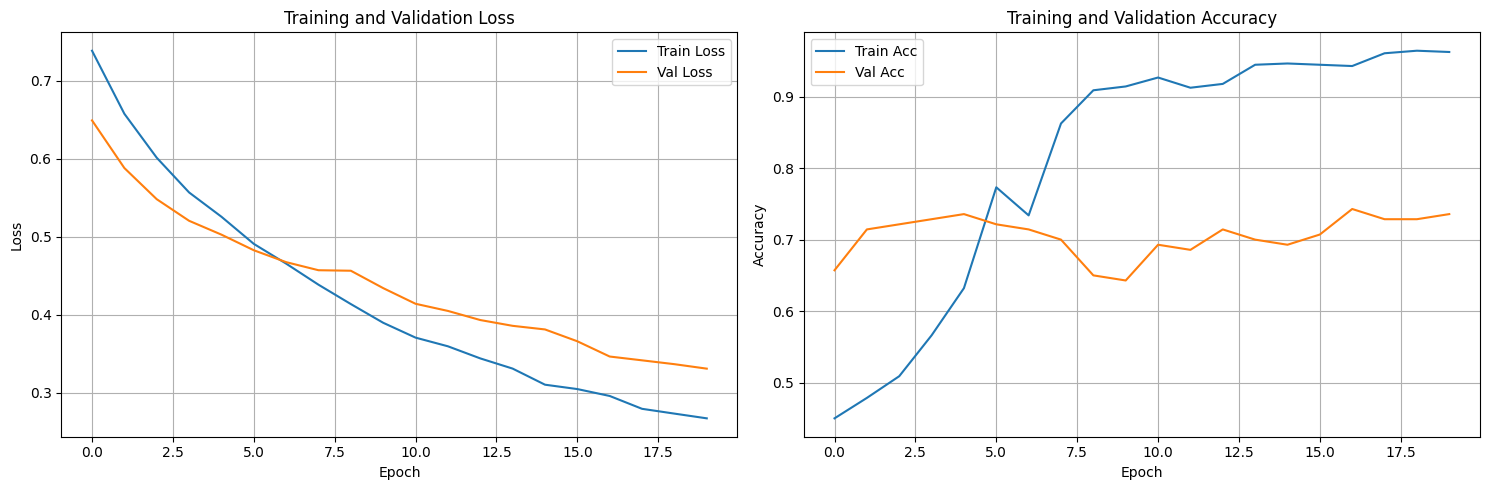

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)
ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_title('Training and Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

Evaluating: 100%|██████████| 5/5 [00:06<00:00,  1.34s/it]


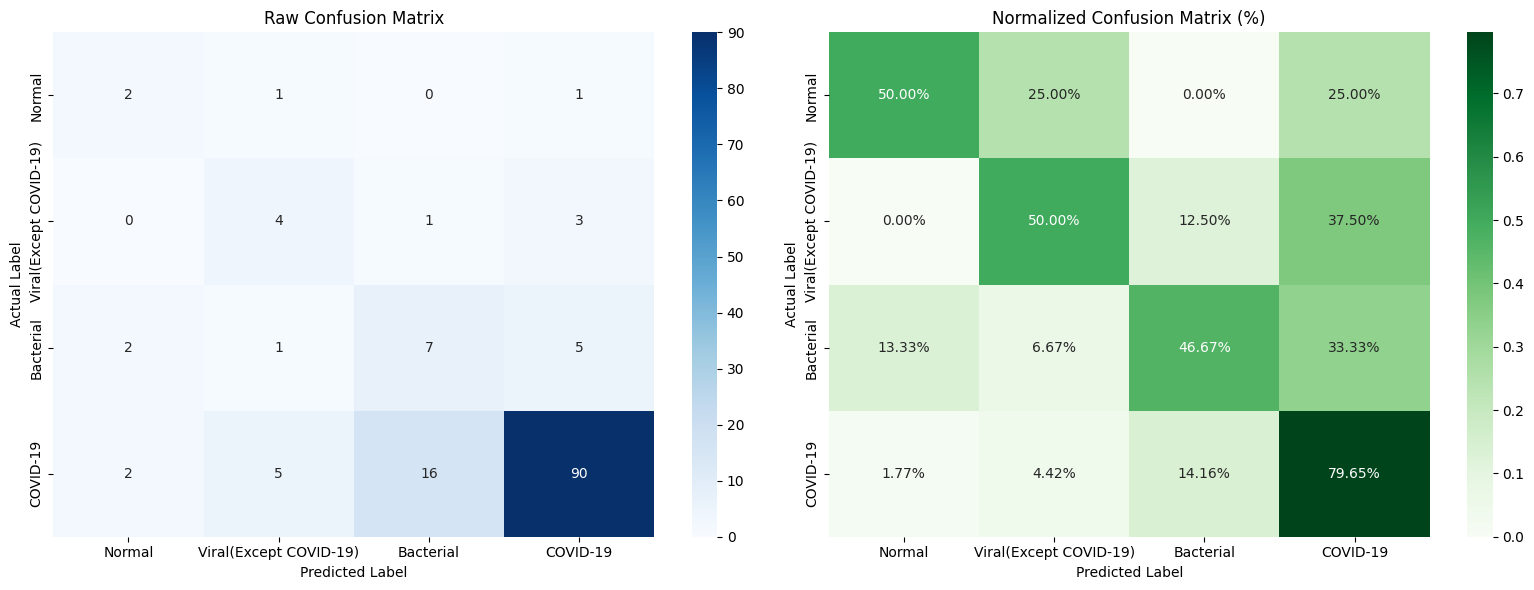


Validation Accuracy (CLIP + LoRA): 0.7357142857142858

Classification Report (CLIP + LoRA):
                        precision    recall  f1-score   support

                Normal     0.3333    0.5000    0.4000         4
Viral(Except COVID-19)     0.3636    0.5000    0.4211         8
             Bacterial     0.2917    0.4667    0.3590        15
              COVID-19     0.9091    0.7965    0.8491       113

              accuracy                         0.7357       140
             macro avg     0.4744    0.5658    0.5073       140
          weighted avg     0.7953    0.7357    0.7593       140



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch.nn.functional as F

@torch.no_grad()
def evaluate_fixed(loader, model, adapter, text_features, logit_scale, device):
    y_true, y_pred = [], []
    model.eval()
    adapter.eval()
    eval_text_features = text_features.to(device)

    for imgs, labels in tqdm(loader, desc="Evaluating"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        if hasattr(outputs, 'last_hidden_state'):
            feats = outputs.last_hidden_state[:, 0, :]
        elif len(outputs.shape) == 3:
            feats = outputs[:, 0, :]
        else:
            feats = outputs
        feats = adapter.get_features(feats)
        feats = F.normalize(feats, dim=-1)
        logits = logit_scale.exp() * (feats @ eval_text_features.T)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    return np.array(y_true), np.array(y_pred)

def plot_medical_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax[0])
    ax[0].set_title("Raw Confusion Matrix")
    ax[0].set_ylabel("Actual Label")
    ax[0].set_xlabel("Predicted Label")
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=ax[1])
    ax[1].set_title("Normalized Confusion Matrix (%)")
    ax[1].set_ylabel("Actual Label")
    ax[1].set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

y_true_eval, y_pred_eval = evaluate_fixed(
    val_loader, model, adapter, text_features, logit_scale, device
)

plot_medical_confusion_matrix(y_true_eval, y_pred_eval, TRAIN_CLASSES)

# PRINT METRICS
print("\nValidation Accuracy (CLIP + LoRA):", accuracy_score(y_true_eval, y_pred_eval))
print("\nClassification Report (CLIP + LoRA):")
print(
    classification_report(
        y_true_eval,
        y_pred_eval,
        target_names=TRAIN_CLASSES,
        digits=4
    )
)



Extracting probabilities for ROC Curve...


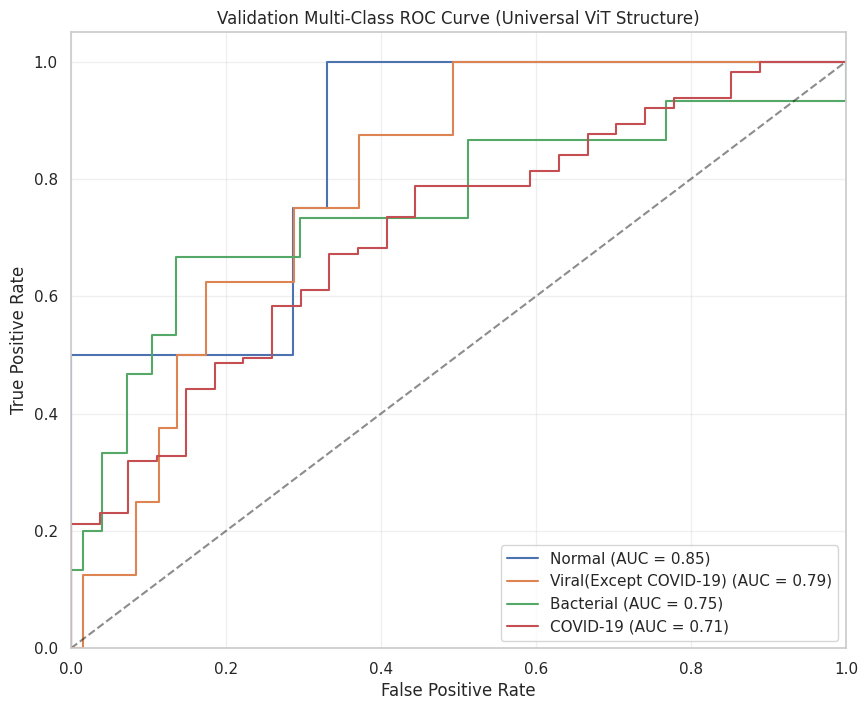

In [ ]:
# @title
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def evaluate_with_probs_universal(loader):
    y_true, y_pred, y_probs = [], [], []
    model.eval()
    adapter.eval()
    final_text_features = text_features # [4, 768]
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        if hasattr(outputs, 'last_hidden_state'):
            feats = outputs.last_hidden_state[:, 0, :]
        elif len(outputs.shape) == 3:
            feats = outputs[:, 0, :]
        else:
            feats = outputs
        feats = adapter.get_features(feats)
        feats = F.normalize(feats, dim=-1)
        logits = logit_scale.exp() * (feats @ final_text_features.T)
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

    return np.array(y_true), np.array(y_pred), np.array(y_probs)

# --- RUN AND PLOT ---
print("Extracting probabilities for ROC Curve...")
val_true_labels, val_predictions, val_probs = evaluate_with_probs_universal(val_loader)
classes = np.unique(val_true_labels)
y_val_bin = label_binarize(val_true_labels, classes=classes)
y_val_scores = np.array(val_probs)

#Plotting
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(TRAIN_CLASSES):
    if i < y_val_bin.shape[1]:
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_val_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Validation Multi-Class ROC Curve (Universal ViT Structure)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Ground Truth for index 0: COVID-19


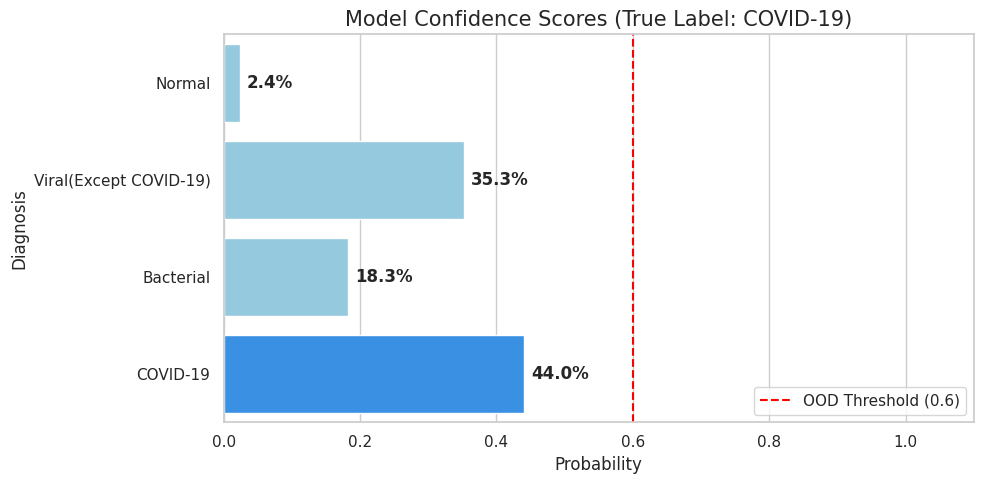

In [ ]:
# ============================================================
# 1. UNIVERSAL INFERENCE HELPER & PLOTTING FUNCTION
# ============================================================
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def get_embeddings(model, adapter, imgs):
    """Universal helper to handle ViT output shapes/types (HF, timm, Hub)"""
    outputs = model(imgs)

    # 1. Handle Hugging Face ViTModel output object
    if hasattr(outputs, 'last_hidden_state'):
        last_hidden_state = outputs.last_hidden_state
    # 2. Handle tuple outputs (sometimes seen in older timm versions)
    elif isinstance(outputs, tuple):
        last_hidden_state = outputs[0]
    # 3. Handle raw Tensors (timm or DINOv2)
    else:
        last_hidden_state = outputs

    # --- UNIVERSAL GUARD: Check dimensions before slicing ---
    if len(last_hidden_state.shape) == 3:
        # If 3D [Batch, Tokens, Dim], extract [CLS] token at index 0
        cls_token = last_hidden_state[:, 0, :]
    else:
        # If 2D [Batch, Dim], it's already the [CLS] token (DINOv2 default)
        cls_token = last_hidden_state

    # Project through adapter and normalize
    projected = adapter.get_features(cls_token)

    return F.normalize(projected, dim=-1)

def plot_confidence_scores(probs, classes, threshold=0.6, title_suffix=""):
    # Convert tensor to a simple list of floats
    if torch.is_tensor(probs):
        probs = probs.squeeze().cpu().detach().numpy()

    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))

    # Create the bar plot
    colors = ['skyblue' if p < max(probs) else 'dodgerblue' for p in probs]
    ax = sns.barplot(x=probs, y=classes, palette=colors, hue=classes, legend=False)

    # Add a vertical line for your OOD threshold
    plt.axvline(x=threshold, color='red', linestyle='--', label=f'OOD Threshold ({threshold})')

    plt.title(f"Model Confidence Scores {title_suffix}", fontsize=15)
    plt.xlabel("Probability", fontsize=12)
    plt.ylabel("Diagnosis", fontsize=12)
    plt.xlim(0, 1.1)
    plt.legend(loc='lower right')

    for i, p in enumerate(probs):
        ax.text(p + 0.01, i, f'{p*100:.1f}%', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# ============================================================
# 2. EXECUTE INFERENCE ON A SINGLE BATCH
# ============================================================
model.eval()
adapter.eval()

# Grab the first batch from the validation loader
imgs, labels = next(iter(val_loader))
imgs, labels = imgs.to(device), labels.to(device)

with torch.no_grad():
    # 1. Get visual features using our new universal helper
    feats = get_embeddings(model, adapter, imgs)

    # 2. Calculate similarity with text anchors
    # (Using the logit_scale parameter from your training setup)
    logits = logit_scale.exp() * (feats @ text_features.T)
    probs_batch = F.softmax(logits, dim=-1)

# ============================================================
# 3. PICK ONE IMAGE AND PLOT
# ============================================================
index_to_plot = 0
single_probs = probs_batch[index_to_plot]
true_label_idx = labels[index_to_plot].item()
true_label_name = TRAIN_CLASSES[true_label_idx]

print(f"Ground Truth for index {index_to_plot}: {true_label_name}")

plot_confidence_scores(
    single_probs,
    TRAIN_CLASSES,
    threshold=0.6,
    title_suffix=f"(True Label: {true_label_name})"
)

In [9]:
ood_test_ds = ChestXrayOODDataset(test_df, transform)

test_loader = DataLoader(
    ood_test_ds,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True if device == "cuda" else False
)

print(f"test_loader is now defined with {len(test_df)} samples.")

test_loader is now defined with 145 samples.


Loading weights from /content/drive/MyDrive/weights/medical_dinov2small2 (4).pth...

--- Starting OOD Evaluation ---


Calculating Energy: 100%|██████████| 5/5 [00:04<00:00,  1.21it/s]


AUROC (OOD higher energy): 0.5816
AUROC (ID higher energy): 0.4184


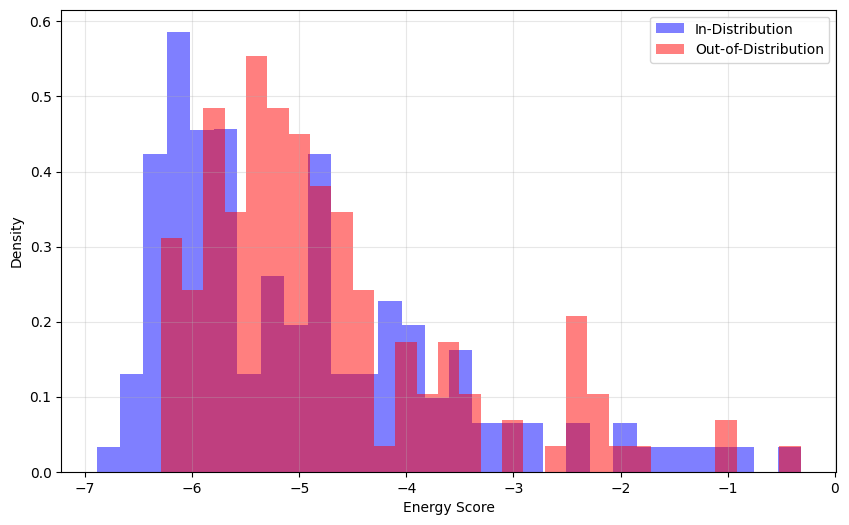

In [15]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. LOAD WEIGHTS

checkpoint_path = "/content/drive/MyDrive/weights/medical_dinov2small2 (4).pth"
print(f"Loading weights from {checkpoint_path}...")

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
adapter.load_state_dict(checkpoint['adapter_state_dict'])
# Use the saved logit scale or default if missing
if 'logit_scale' in checkpoint:
    with torch.no_grad():
        logit_scale.copy_(checkpoint['logit_scale'])

# ============================================================
# 2. ENERGY SCORE FUNCTION
# ============================================================
@torch.no_grad()
def get_energy_scores(dataloader, model, adapter, text_features, T=0.1):
    model.eval()
    adapter.eval()

    energies = []

    for batch in tqdm(dataloader, desc="Calculating Energy"):
        # Robust batch handling
        if isinstance(batch, (list, tuple)):
            images = batch[0].to(device)
        else:
            images = batch.to(device)

        # 1. Forward pass
        outputs = model(images)

        if hasattr(outputs, 'last_hidden_state'):
            hidden_states = outputs.last_hidden_state
        elif isinstance(outputs, tuple):
            hidden_states = outputs[0]
        else:
            hidden_states = outputs
        if len(hidden_states.shape) == 3:
            cls_token = hidden_states[:, 0, :]
        else:
            cls_token = hidden_states
        img_emb = F.normalize(adapter.get_features(cls_token), dim=-1)
        logits = (img_emb @ text_features.t()) * logit_scale.exp()
        energy = -(T * torch.logsumexp(logits / T, dim=1))
        energies.append(energy.cpu().numpy())

    return np.concatenate(energies)

# RUN EVALUATION
print("\n--- Starting OOD Evaluation ---")
id_energy = get_energy_scores(val_loader, model, adapter, text_features)
ood_energy = get_energy_scores(test_loader, model, adapter, text_features)
y_true =np.array([0] * len(id_energy) + [1] * len(ood_energy))
y_scores = np.concatenate([-id_energy, -ood_energy])
auroc_direct = roc_auc_score(y_true, np.concatenate([id_energy, ood_energy]))
auroc_inverted = roc_auc_score(y_true, np.concatenate([-id_energy, -ood_energy]))

print(f"AUROC (OOD higher energy): {auroc_direct:.4f}")
print(f"AUROC (ID higher energy): {auroc_inverted:.4f}")


# PLOT DISTRIBUTIONS

plt.figure(figsize=(10, 6))

# Histogram of Energy Scores
plt.hist(id_energy, bins=30, alpha=0.5, label='In-Distribution', color='blue', density=True)
plt.hist(ood_energy, bins=30, alpha=0.5, label='Out-of-Distribution', color='red', density=True)

plt.xlabel('Energy Score')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
@torch.no_grad()
def analyze_ood_performance(id_loader, ood_loader):
    model.eval()
    adapter.eval()

    def get_scores(loader):
        max_probs = []
        energies = []
        for batch in loader:
            imgs = batch[0] if isinstance(batch, (list, tuple)) else batch
            imgs = imgs.to(device)
            if imgs.ndim == 3:
                imgs = imgs.unsqueeze(0)
            outputs = model(imgs)
            if hasattr(outputs, 'last_hidden_state'):
                feats = outputs.last_hidden_state[:, 0, :]
            elif isinstance(outputs, torch.Tensor) and len(outputs.shape) == 3:
                feats = outputs[:, 0, :]
            else:
                feats = outputs

            feats = adapter.get_features(feats)
            feats = F.normalize(feats, dim=-1)
            logits = logit_scale.exp() * (feats @ text_features.T)

            probs = F.softmax(logits, dim=-1)
            max_probs.append(probs.max(dim=1)[0].cpu())
            energy = torch.logsumexp(logits, dim=1).cpu()
            energies.append(energy)

        return torch.cat(max_probs), torch.cat(energies)

    id_probs, id_energy = get_scores(id_loader)
    ood_probs, ood_energy = get_scores(ood_loader)

    print(f"--- Comparison: ID (Val) vs OOD (Test) ---")
    print(f"Mean Confidence (MSP) | ID: {id_probs.mean():.4f} | OOD: {ood_probs.mean():.4f}")
    print(f"Mean Energy Score    | ID: {id_energy.mean():.4f} | OOD: {ood_energy.mean():.4f}")

    return (id_probs, ood_probs), (id_energy, ood_energy)

prob_results, energy_results = analyze_ood_performance(val_loader, test_loader)

--- Comparison: ID (Val) vs OOD (Test) ---
Mean Confidence (MSP) | ID: 0.7459 | OOD: 0.6451
Mean Energy Score    | ID: 5.2800 | OOD: 5.1987


In [18]:
!pip install fvcore
import torch
import torch.nn as nn
from fvcore.nn import FlopCountAnalysis, parameter_count

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=32cef89692e4850ee5c053a0443010c9225f759d47290f03690e1a086af767ab
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=d84ef1b683ff7ea3b014dd486a62de933ab3d006181543c8089e244a72eecf4d
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


In [21]:
import torch
from fvcore.nn import FlopCountAnalysis, parameter_count

# --- 1. Define Combined Model Wrapper (Updated for timm) ---
class CombinedModel(nn.Module):
    def __init__(self, vit_backbone, adapter_layer):
        super().__init__()
        self.backbone = vit_backbone
        self.adapter = adapter_layer

    def forward(self, x):
        # Forward pass matching your timm training loop
        outputs = self.backbone(x)

        # timm returns the tensor directly [batch, tokens, dim]
        # We slice index 0 for the [CLS] token
        cls_token = outputs[:, 0, :]

        # Pass through the adapter
        adapted_features = self.adapter(cls_token)
        return adapted_features

# Re-instantiate the Wrapper with the fix
analysis_model = CombinedModel(model, adapter).to(device)
analysis_model.eval()

# --- 2. Calculate Parameters ---
# (Your print_trainable_parameters function remains the same)
print("--- Model Parameter Details ---")
print_trainable_parameters(analysis_model)

# --- 3. Calculate GFLOPs ---
dummy_input = torch.randn(1, 3, 224, 224).to(device)

# Using fvcore to analyze FLOPs
flop_analyzer = FlopCountAnalysis(analysis_model, dummy_input)
# Suppress warnings for unsupported operators if necessary
flop_analyzer.unsupported_ops_warnings(False)

total_flops = flop_analyzer.total()
gflops = total_flops / 1e9

print(f"Total GFLOPs: {gflops:.4f}")

--- Model Parameter Details ---


NameError: name 'print_trainable_parameters' is not defined

In [16]:
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import numpy as np

# --- 1. SETUP DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_PATH = "/content/drive/MyDrive/weights/medical_dinov2small2 (4).pth" # Ensure this matches your saved filename

# --- 2. LOAD MODELS ---
# Note: Ensure 'model', 'adapter', 'pubmed_model', and 'pubmed_tokenizer'
# are already defined in your notebook environment before running this.

try:
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)

    # Load weights into your existing objects
    model.load_state_dict(checkpoint['model_state_dict'])
    adapter.load_state_dict(checkpoint['adapter_state_dict'])

    # Load the learnable temperature (logit_scale)
    # We use .data to copy the tensor values safely
    if 'logit_scale' in checkpoint:
        logit_scale.data = checkpoint['logit_scale'].data.to(device)

    print("✅ Checkpoint loaded successfully!")
except Exception as e:
    print(f"❌ Error loading checkpoint: {e}")

model.to(device).eval()
adapter.to(device).eval()
pubmed_model.to(device).eval()

# --- 3. INFERENCE FUNCTION ---
@torch.no_grad()
def analyze_medical_image(image, disease_tags_str):
    if image is None:
        return {"Error": "Please upload an image."}

    # Clean the tags
    tag_list = [t.strip() for t in disease_tags_str.split(",") if t.strip()]
    if not tag_list:
        return {"Error": "Please enter at least one tag."}

    try:
        # A. Preprocess Image (Ensure 'transform' is defined in your notebook)
        img_t = transform(image).unsqueeze(0).to(device)

        # B. Vision Features
        vit_out = model(img_t)
        if hasattr(vit_out, 'last_hidden_state'):
            vision_emb = vit_out.last_hidden_state[:, 0, :]
        elif len(vit_out.shape) == 3:
            vision_emb = vit_out[:, 0, :]
        else:
            vision_emb = vit_out

        # Adapter & Normalize
        projected_vision = adapter.get_features(vision_emb)
        projected_vision = F.normalize(projected_vision, p=2, dim=-1)

        # C. Text Features with Zero-Shot Centering
        all_text_embs = []
        for tag in tag_list:
            prompt = f"a chest x-ray showing signs of {tag.lower()}."
            inputs = pubmed_tokenizer(prompt, padding=True, truncation=True, return_tensors="pt").to(device)
            text_out = pubmed_model(**inputs)
            # Take CLS token
            all_text_embs.append(text_out.last_hidden_state[:, 0, :])

        text_matrix = torch.cat(all_text_embs, dim=0) # [Num_Tags, 768]

        # --- THE ALIGNMENT FIX ---
        # We subtract the mean to break the 0.96+ similarity, matching your training logic
        text_matrix = text_matrix - text_matrix.mean(dim=0, keepdim=True)
        text_matrix = F.normalize(text_matrix, p=2, dim=-1)

        # D. Calculate Logits
        # Use the learned logit_scale. Removed the manual '* 5.0' to keep balance.
        logits = (projected_vision @ text_matrix.T) * logit_scale.exp()

        probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
        return {tag_list[i]: float(probs[i]) for i in range(len(tag_list))}

    except Exception as e:
        return {"Error": f"Inference failed: {str(e)}"}

# --- 2. GRADIO INTERFACE ---
# Note: Using 'soft' as a string to avoid versioning issues with gr.themes
with gr.Blocks(theme='soft') as demo:
    gr.Markdown("# 🫁 Medical Vision-Language Classifier")
    gr.Markdown("Zero-Shot analysis using DINOv2 and PubMedBERT.")

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="pil", label="Chest X-Ray")
            input_tags = gr.Textbox(
                label="Diagnostic Categories (Comma separated)",
                value="COVID-19, Viral Pneumonia, Bacterial Pneumonia, Normal"
            )
            run_btn = gr.Button("Analyze Image", variant="primary")

        with gr.Column():
            output_label = gr.Label(label="Predictions", num_top_classes=5)

    run_btn.click(
        fn=analyze_medical_image,
        inputs=[input_img, input_tags],
        outputs=output_label
    )

# Launch with share=True for Colab
demo.launch(share=True)


✅ Checkpoint loaded successfully!


/tmp/ipykernel_925/2309171744.py:92: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme='soft') as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2ebcb967b87898c2bb.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
